# 05: Channel & Budget Optimization

**Dataset:** Google Analytics Sample Ecommerce Dataset (BigQuery public data)  
**Goal:** Identify the most revenue-efficient traffic channels and model optimal session allocation to maximize revenue under a fixed traffic budget.

**Limitation:** This dataset contains no ad spend data, so optimization cannot work in dollars. Instead, it treats session volume as a proxy for budget - the assumption being that more budget directed at a channel produces more sessions from that channel. Shifting sessions from a low-performing channel to a high-performing one is equivalent to redirecting acquisition effort. In reality, cost per session varies significantly across channels, so results should be read as directional guidance rather than a precise budget split.

## 1. Setup

In [1]:
import os
from google.cloud import bigquery
import pandas as pd
import numpy as np
from scipy import optimize
from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.width', 1000)

os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "../credentials/bq-key.json"
client = bigquery.Client()
print("BigQuery client ready.")

BigQuery client ready.


## 2. Traffic Source Breakdown

`channelGrouping` is GA's derived label built from `trafficSource.source` and `trafficSource.medium`. Before modeling channel efficiency, we verify what is actually behind each label — whether Social is paid or organic, which sites drive Referral, how much AdWords data is populated, and which ad positions and targeting criteria are used.

**Fields explored:**

| Field | Description |
|---|---|
| `trafficSource.source` | Origin (e.g. `google`, `facebook.com`, `(direct)`) |
| `trafficSource.medium` | Acquisition method (e.g. `organic`, `cpc`, `referral`) |
| `trafficSource.campaign` | Campaign name, usually from `utm_campaign` |
| `trafficSource.campaignCode` | `utm_id` tracking parameter for manual campaign tracking |
| `trafficSource.adContent` | Ad content set via `utm_content` parameter |
| `trafficSource.keyword` | Search keyword — paid search, sometimes organic |
| `trafficSource.referralPath` | URL path of the referring page (Referral only) |
| `trafficSource.isTrueDirect` | True if session was genuine direct navigation or bookmark; also true if two consecutive sessions share identical campaign details |
| `adwordsClickInfo.adNetworkType` | `Google Search`, `Content`, `Search partners`, `Ad Exchange`, etc. |
| `adwordsClickInfo.campaignId` | Google Ads campaign ID |
| `adwordsClickInfo.adGroupId` | Google Ads ad group ID |
| `adwordsClickInfo.creativeId` | Google ad creative ID |
| `adwordsClickInfo.criteriaId` | Targeting criterion ID |
| `adwordsClickInfo.criteriaParameters` | Descriptive string for the targeting criterion |
| `adwordsClickInfo.customerId` | Google Ads customer ID |
| `adwordsClickInfo.gclId` | Google Click ID |
| `adwordsClickInfo.isVideoAd` | True if TrueView video ad |
| `adwordsClickInfo.page` | Page number in search results where the ad appeared |
| `adwordsClickInfo.slot` | Ad position: `Top` or `RHS` (right-hand side) |
| `adwordsClickInfo.targetingCriteria.boomUserlistId` | Remarketing list ID if session matched a Google Ads audience list |

In [2]:
# source / medium breakdown per channelGrouping — saved to CSV for full view
# isTrueDirect = TRUE: user navigated directly this session but GA attributed it to a prior channel
# isTrueDirect = NULL: session had a real trackable source
query_source_medium = """
SELECT
    channelGrouping,
    trafficSource.source       AS source,
    trafficSource.medium       AS medium,
    trafficSource.isTrueDirect AS is_true_direct,
    COUNT(*)                   AS sessions,
    SUM(totals.transactions)   AS transactions,
    ROUND(SUM(totals.totalTransactionRevenue) / 1000000, 2) AS revenue
FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
WHERE trafficSource.source != 'analytics.google.com'
GROUP BY channelGrouping, source, medium, is_true_direct
ORDER BY channelGrouping, sessions DESC
"""

df_source_medium = client.query(query_source_medium).to_dataframe()
df_source_medium['transactions'] = df_source_medium['transactions'].fillna(0).astype(int)
df_source_medium['revenue'] = df_source_medium['revenue'].fillna(0)
df_source_medium.to_csv('../data/source_medium_breakdown.csv', index=False)
print(f"Full table: {len(df_source_medium)} rows saved to data/source_medium_breakdown.csv")

# summary: medium + isTrueDirect breakdown per channel
# dropna=False ensures is_true_direct=NaN rows are retained (real trackable sessions)
df_medium_summary = (
    df_source_medium
    .groupby(['channelGrouping', 'medium', 'is_true_direct'], as_index=False, dropna=False)
    .agg(sessions=('sessions', 'sum'), transactions=('transactions', 'sum'), revenue=('revenue', 'sum'))
    .sort_values(['channelGrouping', 'sessions'], ascending=[True, False])
)
display(df_medium_summary)

Full table: 413 rows saved to data/source_medium_breakdown.csv


,channelGrouping,medium,is_true_direct,sessions,transactions,revenue
3,(Other),(not set),<NA>,100,1,11.99
2,(Other),(not set),True,17,0,0.00
1,(Other),(none),<NA>,2,0,0.00
0,(Other),(none),True,1,0,0.00
5,Affiliates,affiliate,<NA>,13466,4,326.57
4,Affiliates,affiliate,True,2937,5,327.81
6,Direct,(none),True,143024,2219,498530.03
7,Direct,(none),<NA>,2,0,0.00
11,Display,cpm,<NA>,4580,74,12769.54
10,Display,cpm,True,1604,76,117489.75


**Insights (source/medium):**

- **Social** - all sessions have `medium = referral`, meaning users clicked links on social platforms. No `medium = cpc` is present, so there are no explicitly tagged paid social campaigns in this dataset.
- **Referral revenue is mostly attribution, not link clicks** - genuine referral link clicks (`medium = referral`, `is_true_direct = NaN`) account for only 15,489 sessions and `$13K`. The remaining `$704K` breaks into: 32,630 direct navigations attributed back via last-non-direct-click (`is_true_direct = True`, `medium = none`, `$456K`); 36,303 sessions with no trackable medium, likely stripped referrers (`$223K`); and 4,244 sessions with `medium = referral` but `is_true_direct = True`, likely repeat visits with identical campaign details (`$25K`).
- **Display AOV is inflated by attribution** - genuine Display ad clicks (`is_true_direct = NaN`) are 4,580 sessions at `$2.79`/session; attributed returning visitors (`is_true_direct = True`) are 1,604 sessions at `$73`/session. The high channel AOV seen in Section 3 comes almost entirely from the latter group.
- **Paid Search is half-untagged** - 10,386 sessions have `medium = cpc` (properly tagged); 10,151 have `medium = (none)`, classified by GA based on gclId presence rather than UTM parameters.
- **Organic Search with no medium tag** - 120,642 sessions are classified as Organic Search despite having `medium = (none)`. GA likely derives the Organic Search label from the referrer domain (e.g. google.com) even without a `medium = organic` tag; the mechanism varies by browser and referrer configuration.

In [3]:
# isTrueDirect: distinguishes genuine direct navigation from GA's last-non-direct-click attribution
# NULL = session had a real trackable source; TRUE = user typed URL/bookmark, or repeated same campaign as prior session
query_true_direct = """
SELECT
    trafficSource.isTrueDirect AS is_true_direct,
    channelGrouping,
    COUNT(*)                   AS sessions,
    SUM(totals.transactions)   AS transactions,
    ROUND(SUM(totals.totalTransactionRevenue) / 1000000, 2) AS revenue,
    ROUND(SAFE_DIVIDE(SUM(totals.transactions), COUNT(*)) * 100, 2) AS conversion_rate
FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
GROUP BY is_true_direct, channelGrouping
ORDER BY is_true_direct DESC, sessions DESC
"""

df_true_direct = client.query(query_true_direct).to_dataframe()
df_true_direct['transactions'] = df_true_direct['transactions'].fillna(0).astype(int)
df_true_direct['revenue'] = df_true_direct['revenue'].fillna(0)
display(df_true_direct)

,is_true_direct,channelGrouping,sessions,transactions,revenue,conversion_rate
0,True,Direct,143024,2219,498530.03,1.55
1,True,Organic Search,68134,1619,218791.92,2.38
2,True,Referral,40356,3347,481444.08,8.29
3,True,Social,13132,63,4866.11,0.48
4,True,Paid Search,4789,121,14040.51,2.53
5,True,Affiliates,2937,5,327.81,0.17
6,True,Display,1615,77,117526.73,4.77
7,True,(Other),18,0,0.00,NaN
8,<NA>,Organic Search,313427,1962,158283.89,0.63
9,<NA>,Social,212985,68,3530.67,0.03


**Insights (isTrueDirect):**

- **Direct channel is genuinely direct** - 143,024 of 143,026 Direct sessions have `isTrueDirect = TRUE`, confirming these are real URL/bookmark navigations, not misattributed traffic.
- **Referral has 40,356 `is_true_direct=True` sessions** - users who navigated directly on that visit but GA credits a prior referral touchpoint via last-non-direct-click attribution. These appear as `source=(direct)` in the referral paths breakdown below, meaning high-intent returning users, not active link clicks.
- **Organic Search has 68,134 `is_true_direct=True` sessions** - returning users who typed the URL directly but are credited to a prior organic session, inflating that channel's transaction count.
- **Implication for the optimization model** - Referral and Organic Search headline revenues include a meaningful share of returning, high-intent visitors whose last trackable touchpoint happened to be that channel, not new sessions actively driven by it.

In [4]:
# adwordsClickInfo field coverage
# which ad network types appear, how many sessions have AdWords data, and their revenue contribution
query_adwords = """
SELECT
    trafficSource.adwordsClickInfo.adNetworkType   AS ad_network_type,
    COUNTIF(trafficSource.adwordsClickInfo.isVideoAd = TRUE) AS video_ad_sessions,
    COUNT(*)                                       AS sessions,
    SUM(totals.transactions)                       AS transactions,
    ROUND(SUM(totals.totalTransactionRevenue) / 1000000, 2) AS revenue,
    -- additional adwords fields: check population rate
    COUNTIF(trafficSource.adwordsClickInfo.campaignId  IS NOT NULL) AS has_campaign_id,
    COUNTIF(trafficSource.adwordsClickInfo.adGroupId   IS NOT NULL) AS has_ad_group_id,
    COUNTIF(trafficSource.adwordsClickInfo.creativeId  IS NOT NULL) AS has_creative_id,
    COUNTIF(trafficSource.adwordsClickInfo.gclId       IS NOT NULL) AS has_gclid,
    COUNTIF(trafficSource.adwordsClickInfo.criteriaParameters IS NOT NULL) AS has_criteria_params,
    COUNTIF(trafficSource.adContent IS NOT NULL)       AS has_ad_content
FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
WHERE trafficSource.source != 'analytics.google.com'
GROUP BY ad_network_type
ORDER BY sessions DESC
"""

df_adwords = client.query(query_adwords).to_dataframe()
df_adwords['transactions'] = df_adwords['transactions'].fillna(0).astype(int)
df_adwords['revenue'] = df_adwords['revenue'].fillna(0)
display(df_adwords)

,ad_network_type,video_ad_sessions,sessions,transactions,revenue,has_campaign_id,has_ad_group_id,has_creative_id,has_gclid,has_criteria_params,has_ad_content
0,NaN,0,866021,11650,1733616.51,0,0,0,101,866021,3730
1,Google Search,0,21453,465,46532.72,0,0,0,21453,21453,7209
2,Search partners,0,7,0,0.00,0,0,0,7,7,7


**Insights (AdWords fields):**

- **campaignId, adGroupId, creativeId** - all 0; not exposed in the demo dataset, so campaign-level or ad-level breakdown is impossible.
- **gclId** - populated for all 21,453 Google Search sessions, confirming all Paid Search went through Google Ads. The 101 gclId hits in the NULL network group are likely misclassified Display sessions.
- **criteriaParameters** - populated for all Google Search sessions but shows "not available in demo dataset" for every row; targeting details are obfuscated.
- **No video ads, no Ad Exchange** - `isVideoAd` is 0 everywhere; Ad Exchange and Yahoo Japan do not appear. Search partners account for only 7 sessions.
- **adContent** - populated for 3,730 non-AdWords sessions, likely manually tagged campaigns using `utm_content` rather than Google Ads auto-tagging.

In [5]:
# keyword coverage: top keywords with session and revenue, excluding placeholder values
query_keywords = """
SELECT
    channelGrouping,
    trafficSource.keyword AS keyword,
    COUNT(*)              AS sessions,
    SUM(totals.transactions) AS transactions,
    ROUND(SUM(totals.totalTransactionRevenue) / 1000000, 2) AS revenue
FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
WHERE trafficSource.source != 'analytics.google.com'
  AND trafficSource.keyword IS NOT NULL
  AND trafficSource.keyword NOT IN ('(not provided)', '(not set)')
GROUP BY channelGrouping, keyword
ORDER BY sessions DESC
LIMIT 30
"""

df_keywords = client.query(query_keywords).to_dataframe()
df_keywords['transactions'] = df_keywords['transactions'].fillna(0).astype(int)
df_keywords['revenue'] = df_keywords['revenue'].fillna(0)
display(df_keywords)

,channelGrouping,keyword,sessions,transactions,revenue
0,Paid Search,6qEhsCssdK0z36ri,4649,112,10007.64
1,Paid Search,google merchandise store,1556,39,4872.91
2,Paid Search,Google Merchandise,1396,44,9210.07
3,Paid Search,1hZbAqLCbjwfgOH7,1258,26,1770.00
4,Paid Search,(Remarketing/Content targeting),886,5,296.79
5,Paid Search,google store,589,0,0.00
6,Organic Search,youtube,459,0,0.00
7,Paid Search,1X4Me6ZKNV0zg-jV,297,3,104.64
8,Organic Search,google merchandise store,276,2,128.94
9,Paid Search,+Google +Merchandise,262,5,955.19


**Insights (keywords):**

- **Largest keyword groups are hashed** - `6qEhsCssdK0z36ri` (4,649 sessions, `$10K`) and `1hZbAqLCbjwfgOH7` (1,258 sessions); Google obfuscates auto-targeting and Smart Bidding keywords.
- **All readable Paid Search keywords are branded** - "google merchandise store", "Google Merchandise", "YouTube Merchandise", "google store". No generic product keywords appear; the campaign is purely brand capture, not discovery.
- **Organic Search keywords are also entirely branded** - youtube, google store, google merchandise. No evidence of product-led organic discovery.
- **Keyword placeholders** - `(Remarketing/Content targeting)` and `(User vertical targeting)` are GA labels for Display/audience targeting sessions flowing through Paid Search, not real search terms.

In [ ]:
# top referral sources and paths — excludes analytics.google.com (internal traffic)
query_referral = """
SELECT
    trafficSource.source       AS source,
    trafficSource.referralPath AS referral_path,
    COUNT(*)                   AS sessions,
    SUM(totals.transactions)   AS transactions,
    ROUND(SUM(totals.totalTransactionRevenue) / 1000000, 2) AS revenue
FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
WHERE channelGrouping = 'Referral'
  AND trafficSource.source != 'analytics.google.com'
GROUP BY source, referral_path
ORDER BY sessions DESC
LIMIT 30
"""

df_referral = client.query(query_referral).to_dataframe()
df_referral['transactions'] = df_referral['transactions'].fillna(0).astype(int)
df_referral['revenue'] = df_referral['revenue'].fillna(0)
display(df_referral)

,source,referral_path,sessions,transactions,revenue
0,(direct),/,67236,5324,676328.09
1,google.com,/permissions/using-the-logo.html,3683,5,380.24
2,siliconvalley.about.com,/od/Things-To-Do-in-Silicon-Valley/fl/How-To-Visit-the-Googleplex-the-Google...,2056,6,412.22
3,qiita.com,/YKEI_mrn/items/c10b14f9a69ff71b1b7a,1784,0,0.00
4,sites.google.com,/a/google.com/googletopia/discounts-deals-and-free-stuff/alphabet-google-dis...,1118,12,1909.81
5,(direct),/offer/2145,1064,20,2300.32
6,mail.google.com,/mail/u/0/,1034,63,24337.18
7,blog.golang.org,/gopher,742,0,0.00
8,sites.google.com,/a/google.com/google-merchandise-store/on-site-store/mountain-view-store,518,12,1796.32
9,sites.google.com,/a/google.com/google-merchandise-store/on-site-store,504,9,929.63


**Insights (referral paths):**

- **source=(direct), the largest segment** - 67,236 sessions, 5,324 transactions, `$676K`. As shown in the isTrueDirect breakdown above, these are attributed returning visitors: users who navigated directly but whose most recent prior touchpoint was a referral link. The 7.9% conversion rate reflects high-intent repeat behavior, not active link clicking.
- **mail.google.com** - 1,034 sessions, 63 transactions, `$24K`, ~6% conversion. Likely internal promotional emails driving high-intent purchases.
- **Most high-traffic external referrals convert near zero** - google.com logo permissions page (3,683 sessions, 5 transactions), qiita.com Japanese tech blog (1,784, 0), blog.golang.org (742, 0). Informational visitors with no purchase intent.
- **dealspotr.com** - 494 sessions combined, 39 transactions, `$5,819` - the only external deal site with meaningful conversion; shows coupon/deal partnerships can drive real revenue.
- **googleads.g.doubleclick.net** - 101 Display ad sessions misclassified as Referral, likely due to missing UTM tags on those creatives.

In [7]:
# ad slot and page position for Paid Search sessions
# slot: Top = above organic results, RHS = right-hand side column
# page: which search results page the ad appeared on
query_slot = """
SELECT
    trafficSource.adwordsClickInfo.slot              AS slot,
    trafficSource.adwordsClickInfo.page              AS page,
    trafficSource.adwordsClickInfo.criteriaParameters AS criteria_parameters,
    COUNT(*)                                         AS sessions,
    SUM(totals.transactions)                         AS transactions,
    ROUND(SUM(totals.totalTransactionRevenue) / 1000000, 2) AS revenue,
    ROUND(SUM(totals.transactions) / COUNT(*) * 100, 2)     AS conversion_rate
FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
WHERE trafficSource.adwordsClickInfo.adNetworkType = 'Google Search'
GROUP BY slot, page, criteria_parameters
ORDER BY sessions DESC
LIMIT 20
"""

df_slot = client.query(query_slot).to_dataframe()
df_slot['transactions'] = df_slot['transactions'].fillna(0).astype(int)
df_slot['revenue'] = df_slot['revenue'].fillna(0)
display(df_slot)

,slot,page,criteria_parameters,sessions,transactions,revenue,conversion_rate
0,Top,1,not available in demo dataset,20897,459,46040.88,2.20
1,RHS,1,not available in demo dataset,458,6,491.84,1.31
2,Top,2,not available in demo dataset,55,0,0.00,NaN
3,RHS,2,not available in demo dataset,18,0,0.00,NaN
4,RHS,3,not available in demo dataset,9,0,0.00,NaN
5,RHS,5,not available in demo dataset,6,0,0.00,NaN
6,RHS,7,not available in demo dataset,2,0,0.00,NaN
7,RHS,9,not available in demo dataset,2,0,0.00,NaN
8,Top,5,not available in demo dataset,1,0,0.00,NaN
9,RHS,4,not available in demo dataset,1,0,0.00,NaN


**Insights (slot & page):**

- **Top position, Page 1 dominates completely** - 20,897 sessions (97.4% of all Google Search clicks), 459 transactions, 2.2% conversion. Almost all paid search spend lands in the top position on the first results page.
- **Top converts better than RHS** - 2.20% vs 1.31% on Page 1. Top ads appear above organic results and draw higher click quality.
- **Pages 2+ are negligible** - 75 sessions combined across all positions beyond page 1, zero transactions.

In [8]:
# remarketing list coverage: sessions where targetingCriteria.boomUserlistId is populated
# a non-null boomUserlistId means this click matched a Google Ads remarketing audience
query_remarketing = """
SELECT
    trafficSource.adwordsClickInfo.targetingCriteria.boomUserlistId AS remarketing_list_id,
    trafficSource.adwordsClickInfo.adNetworkType                    AS ad_network_type,
    COUNT(*)                                                        AS sessions,
    SUM(totals.transactions)                                        AS transactions,
    ROUND(SUM(totals.totalTransactionRevenue) / 1000000, 2)        AS revenue
FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
WHERE trafficSource.adwordsClickInfo.targetingCriteria.boomUserlistId IS NOT NULL
GROUP BY remarketing_list_id, ad_network_type
ORDER BY sessions DESC
"""

df_remarketing = client.query(query_remarketing).to_dataframe()
df_remarketing['transactions'] = df_remarketing['transactions'].fillna(0).astype(int)
df_remarketing['revenue'] = df_remarketing['revenue'].fillna(0)
display(df_remarketing)

,remarketing_list_id,ad_network_type,sessions,transactions,revenue


**Insights (remarketing):**

- **No remarketing sessions in this dataset** - `boomUserlistId` is NULL for every session. Either no Google Ads remarketing campaigns were active during the period, or the demo dataset strips this field. Remarketing list-based analysis is not possible here.

In [9]:
# campaignCode (utm_id) coverage: how many sessions use manual utm_id tracking
# distinct from campaign name — utm_id is a numeric/alphanumeric ID for linking to external systems
query_campaign_code = """
SELECT
    trafficSource.campaignCode AS campaign_code,
    trafficSource.campaign     AS campaign_name,
    channelGrouping,
    COUNT(*)                   AS sessions,
    SUM(totals.transactions)   AS transactions,
    ROUND(SUM(totals.totalTransactionRevenue) / 1000000, 2) AS revenue
FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
WHERE trafficSource.campaignCode IS NOT NULL
GROUP BY campaign_code, campaign_name, channelGrouping
ORDER BY sessions DESC
"""

df_campaign_code = client.query(query_campaign_code).to_dataframe()
df_campaign_code['transactions'] = df_campaign_code['transactions'].fillna(0).astype(int)
df_campaign_code['revenue'] = df_campaign_code['revenue'].fillna(0)
display(df_campaign_code)

,campaign_code,campaign_name,channelGrouping,sessions,transactions,revenue
0,11251kjhkvahf,(not set),(Other),1,0,0.0


**Insights (campaignCode):**

- **utm_id is not used** - only 1 session has a `campaignCode` set, with no campaign name and no transactions. Manual campaign ID tracking via `utm_id` is absent from this dataset; all campaign attribution relies on `utm_campaign` name or auto-tagging via gclId.

## 3. Channel Baseline
*Full-year sessions, transactions, revenue, and conversion rate by channel. Excludes `analytics.google.com`*

In [10]:
query_channel_baseline = """
SELECT
    channelGrouping,
    COUNT(*) AS sessions,
    SUM(totals.transactions) AS transactions,
    ROUND(SUM(totals.totalTransactionRevenue) / 1000000, 2) AS revenue
FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
WHERE trafficSource.source != 'analytics.google.com'
GROUP BY channelGrouping
ORDER BY sessions DESC
"""

df_channels = client.query(query_channel_baseline).to_dataframe()
df_channels['transactions'] = df_channels['transactions'].fillna(0).astype(int)
df_channels['revenue'] = df_channels['revenue'].fillna(0)
df_channels['conversion_rate'] = (df_channels['transactions'] / df_channels['sessions'] * 100).round(2)
df_channels['revenue_per_session'] = (df_channels['revenue'] / df_channels['sessions']).round(4)
df_channels['avg_order_value'] = (
    df_channels['revenue'] / df_channels['transactions'].replace(0, np.nan)
).round(2)

display(df_channels)

,channelGrouping,sessions,transactions,revenue,conversion_rate,revenue_per_session,avg_order_value
0,Organic Search,381561,3581,377075.81,0.94,0.9882,105.30
1,Social,226117,131,8396.78,0.06,0.0371,64.10
2,Direct,143026,2219,498530.03,1.55,3.4856,224.66
3,Referral,88666,5543,717600.25,6.25,8.0933,129.46
4,Paid Search,25326,479,47543.43,1.89,1.8773,99.26
5,Affiliates,16403,9,654.38,0.05,0.0399,72.71
6,Display,6262,152,130336.56,2.43,20.8139,857.48
7,(Other),120,1,11.99,0.83,0.0999,11.99


**Note:** Full channel performance analysis - bounce rate, AOV, monthly mix shift, and campaign breakdown - is covered in `02_eda.ipynb` (Sections 7-8). This section uses the same baseline query as a starting point for the optimization model.

- **Referral is the highest-quality channel**: 6.25% conversion, `$8.09` revenue/session, `$717K` total revenue, highest revenue despite ranking 4th in sessions. Note: as shown in Section 2, most of this revenue came from users who returned directly in a later session; the referral link was the acquisition touchpoint, and GA credits it via last-non-direct-click attribution.
- **Social is volume without value**: 226K sessions (2nd) but only 0.06% conversion and `$0.04` revenue/session
- **Display shows the highest revenue/session (`$20.81`)** but only 6,262 sessions and `$857` AOV - Section 2 shows this is driven by 1,604 `is_true_direct=True` sessions at `$73` per session (attribution artifact), not genuine ad click performance
- **Organic Search is the volume engine**: 381K sessions at `$0.99`/session - low yield per session but too large to ignore; small efficiency gains here compound significantly at this scale

## 4. Channel Efficiency
*Revenue per session (yield) = revenue / sessions, combining conversion rate and order value into a single efficiency metric.   
Plotting yield against session volume shows which channels are underscaled (high yield, low volume) vs overscaled (low yield, high volume).*

Channel performance from `02_eda.ipynb`:

![channel performance](../images/channel_performance.png)

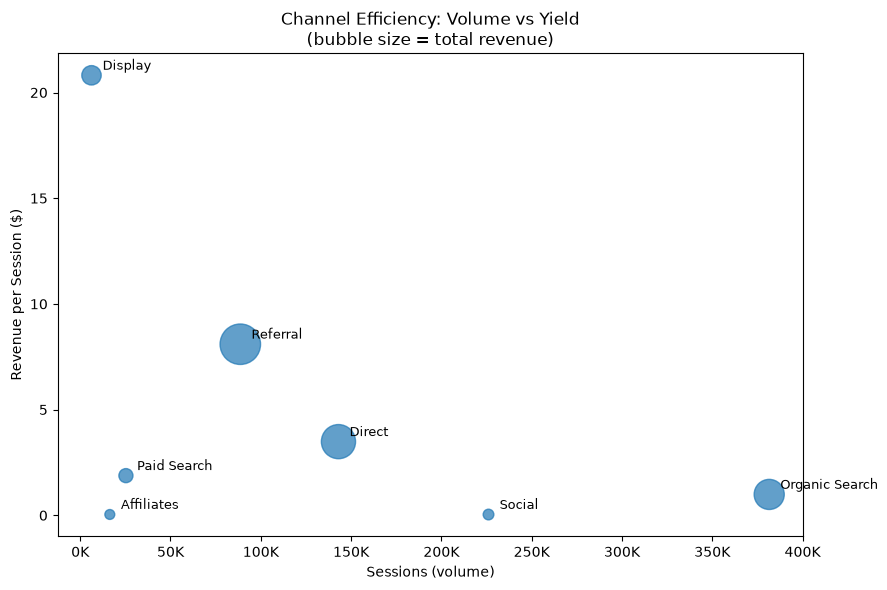

In [ ]:
# exclude (Other) - minor session, not a meaningful channel
df_plot = df_channels[df_channels['channelGrouping'] != '(Other)'].copy()

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(df_plot['sessions'], df_plot['revenue_per_session'],
           s=df_plot['revenue'] / df_plot['revenue'].max() * 800 + 50,
           alpha=0.7, color='tab:blue')

for _, row in df_plot.iterrows():
    ax.annotate(row['channelGrouping'],
                xy=(row['sessions'], row['revenue_per_session']),
                xytext=(8, 4), textcoords='offset points', fontsize=9)

ax.set_xlabel('Sessions (volume)')
ax.set_ylabel('Revenue per Session ($)')
ax.set_title('Channel Efficiency: Volume vs Yield\n(bubble size = total revenue)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

plt.tight_layout()
plt.savefig('../images/channel_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()

**Insights:**

- **Referral is underscaled** - highest yield with a revenue bubble that already outweighs channels with far more sessions. Growing Referral means more acquisition touchpoints, not same-session conversions.
- **Display is an outlier, not a signal** - top-left isolated position reflects a handful of large attributed orders at very low volume, not consistent channel performance
- **Social and Affiliates are volume without yield** - Social ranks 2nd in sessions but its revenue bubble is disproportionately small; prime candidates for reallocation
- **Organic Search is the efficiency lever** - the biggest volume by far at low yield; small conversion gains here compound more than scaling any smaller channel
- **Direct is self-sustaining** - solid yield and high AOV suggest returning, intent-driven visitors; not a channel to artificially push spend into

## 5. Diminishing Returns Model
Adding more sessions to a channel does not linearly increase revenue - channels saturate as the most engaged audience is already captured. A logarithmic model captures this: `revenue(s) = a * log(s + 1)`, where `a` is fitted per channel from the baseline data.

This assumption is necessary because we have only one observation per channel (full-year total). The log model is a standard choice for saturation curves and ensures the optimizer cannot recommend infinite scaling of a single channel.

**Limitations of the log model:**
- Fitted through a single data point per channel - the shape of diminishing returns is imposed by the function, not learned from data
- Assumes returns diminish from the very first session; does not capture channels that need critical mass before becoming effective (e.g. Paid Search, where the algorithm learns at higher volume)
- No seasonality correction - the single observed point reflects a full year of mixed conditions
- A more flexible alternative is the Hill saturation function (used in Bayesian MMM), but fitting it requires multiple data points per channel

In [12]:
# fit log model per channel: revenue = a * log(sessions + 1)
# a is solved from the single observed (sessions, revenue) point: a = revenue / log(sessions + 1)
df_model = df_channels[df_channels['channelGrouping'] != '(Other)'].copy().reset_index(drop=True)

df_model['log_coef'] = df_model['revenue'] / np.log(df_model['sessions'] + 1)

# sanity check: projected revenue at 2x current sessions vs actual
df_model['rev_at_2x'] = (df_model['log_coef'] * np.log(df_model['sessions'] * 2 + 1)).round(0)
df_model['marginal_yield_2x'] = ((df_model['rev_at_2x'] - df_model['revenue']) / df_model['sessions']).round(4)

display(df_model[['channelGrouping', 'sessions', 'revenue', 'log_coef',
                   'rev_at_2x', 'marginal_yield_2x']].sort_values('log_coef', ascending=False))

,channelGrouping,sessions,revenue,log_coef,rev_at_2x,marginal_yield_2x
3,Referral,88666,717600.25,62988.039414,761260.0,0.4924
2,Direct,143026,498530.03,41996.369617,527640.0,0.2035
0,Organic Search,381561,377075.81,29339.789131,397413.0,0.0533
6,Display,6262,130336.56,14908.531135,140669.0,1.65
4,Paid Search,25326,47543.43,4688.873988,50793.0,0.1283
1,Social,226117,8396.78,681.069662,8869.0,0.0021
5,Affiliates,16403,654.38,67.425151,701.0,0.0028


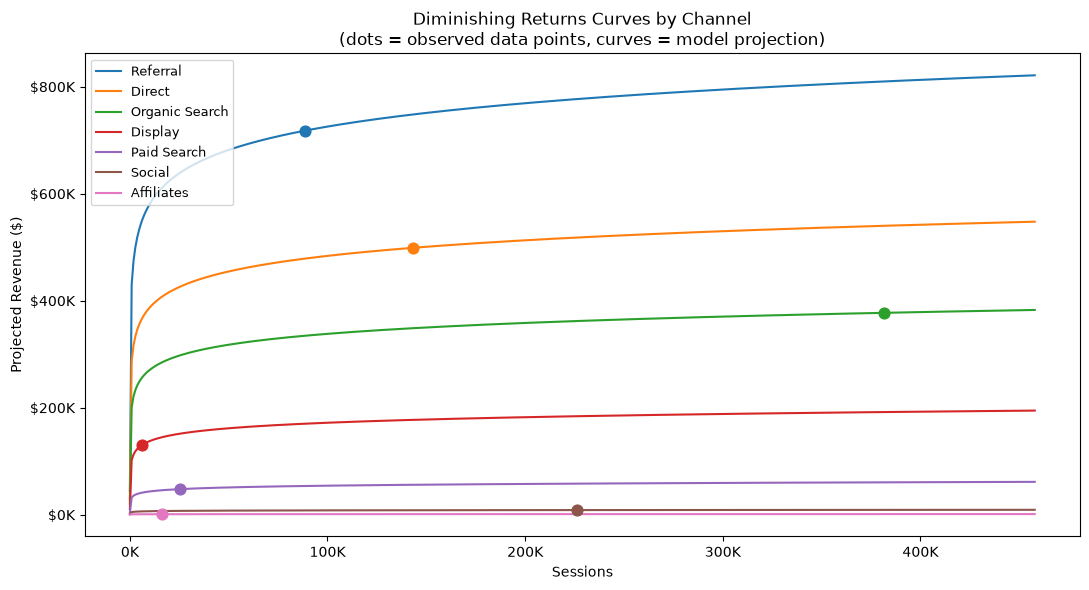

In [13]:
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red',
          'tab:purple', 'tab:brown', 'tab:pink']

s_range = np.linspace(1, df_model['sessions'].max() * 1.2, 500)

fig, ax = plt.subplots(figsize=(11, 6))

for i, (_, row) in enumerate(df_model.sort_values('log_coef', ascending=False).iterrows()):
    rev_curve = row['log_coef'] * np.log(s_range + 1)
    ax.plot(s_range, rev_curve, color=colors[i], linewidth=1.5, label=row['channelGrouping'])
    ax.scatter(row['sessions'], row['revenue'], color=colors[i], s=60, zorder=5)

ax.set_xlabel('Sessions')
ax.set_ylabel('Projected Revenue ($)')
ax.set_title('Diminishing Returns Curves by Channel\n(dots = observed data points, curves = model projection)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('../images/diminishing_returns.png', dpi=150, bbox_inches='tight')
plt.show()

**Observations:**

- **Referral has the steepest curve** (highest log_coef) - the most fundamentally efficient channel; but diminishing returns are already significant: doubling sessions grows revenue by only ~6% (`$718K` to `$761K`). Growing Referral means more acquisition touchpoints, not same-session conversions.
- **Organic Search is deeply saturated** - at 381K sessions it is far along its curve; marginal yield at 2x is just `$0.05`/session, meaning adding more Organic sessions barely moves total revenue
- **Social and Affiliates are essentially flat** - marginal yield at 2x is near zero (`$0.002`); these are the clearest candidates for reallocation
- **Display is a model outlier** - highest marginal yield at 2x (`$1.65`) because it has so few sessions it is still on the steep part of the curve; however, this is an artifact of attribution-inflated AOV, not reliable channel performance; the optimizer will cap Display in Section 6

## 6. Optimization
*Find the session allocation across controllable channels that maximizes total projected revenue, keeping their combined session count fixed.*

**Channel controllability:**
- **Fixed** (Organic Search, Direct): session volumes are determined by user intent and search engine ranking, not directly purchasable or reducible via spend decisions. Excluded from the optimizer.
- **Controllable** (Paid Search, Display, Affiliates, Social, Referral): sessions can be scaled through budget allocation, partnerships, or campaign changes.

**Constraints and bounds (controllable channels only):**
- Total sessions across controllable channels must equal their current combined total
- Each channel: minimum 30% of current sessions (floor to avoid eliminating any channel)
- Each channel: maximum 3x current sessions, except Display which is capped at 1.5x (outlier AOV makes its log_coef unreliable as a scaling signal)

The optimizer uses SLSQP (Sequential Least Squares Programming) via `scipy.optimize.minimize`. The log revenue function is concave, so the optimizer will always converge to the global optimum.

In [ ]:
# separate channels by controllability
# fixed: Organic Search, Direct — sessions driven by user intent/SEO, not purchasable
# controllable: Paid Search, Display, Affiliates, Social, Referral — adjustable via spend/campaigns
fixed_channels = ['Organic Search', 'Direct']

df_fixed = df_model[df_model['channelGrouping'].isin(fixed_channels)].copy()
df_ctrl  = df_model[~df_model['channelGrouping'].isin(fixed_channels)].copy().reset_index(drop=True)

channels_ctrl = df_ctrl['channelGrouping'].tolist()
s0_ctrl = df_ctrl['sessions'].values.astype(float)  # current session counts (starting point)
a_ctrl  = df_ctrl['log_coef'].values                # revenue efficiency per channel

total_sessions_ctrl = s0_ctrl.sum()  # budget constraint: total must stay fixed

# objective: maximize total projected revenue across controllable channels
# scipy only provides minimize(), so need to negate the revenue
def neg_revenue(s):
    return -np.sum(a_ctrl * np.log(s + 1))

# gradient of neg_revenue: derivative of -a*log(s+1) is -a/(s+1)
# providing this makes the optimizer faster and more accurate
def neg_revenue_grad(s):
    return -a_ctrl / (s + 1)

# equality constraint: total sessions must equal current total (fixed budget)
# scipy requires constraints as f(s) = 0, so: s.sum() - total = 0
constraints = [{'type': 'eq', 'fun': lambda s: s.sum() - total_sessions_ctrl}]

bounds = []
for ch, s_cur in zip(channels_ctrl, s0_ctrl):
    lo = s_cur * 0.3          # floor: no channel drops below 30% of current
    hi = s_cur * 1.5 if ch == 'Display' else s_cur * 3.0
    bounds.append((lo, hi))

result = optimize.minimize(
    neg_revenue, s0_ctrl, jac=neg_revenue_grad,
    method='SLSQP', bounds=bounds, constraints=constraints,
    options={'ftol': 1e-10, 'maxiter': 2000}
)

rev_fixed    = np.sum(df_fixed['log_coef'].values * np.log(df_fixed['sessions'].values + 1))
rev_ctrl_cur = np.sum(a_ctrl * np.log(s0_ctrl + 1))
rev_ctrl_opt = -result.fun

print(f"Optimizer status: {'SUCCESS' if result.success else 'FAILED'} — {result.message}")
print(f"Fixed channels (Organic + Direct) revenue:   ${rev_fixed:,.0f}  (unchanged)")
print(f"Controllable channels — baseline revenue:    ${rev_ctrl_cur:,.0f}")
print(f"Controllable channels — optimized revenue:   ${rev_ctrl_opt:,.0f}")
print(f"Total optimized revenue:                     ${rev_fixed + rev_ctrl_opt:,.0f}  (vs baseline ${rev_fixed + rev_ctrl_cur:,.0f})")

Optimizer status: SUCCESS — Optimization terminated successfully
Fixed channels (Organic + Direct) revenue:   $875,606  (unchanged)
Controllable channels — baseline revenue:    $904,531
Controllable channels — optimized revenue:   $976,483
Total optimized revenue:                     $1,852,089  (vs baseline $1,780,137)


In [15]:
s_opt = result.x

# controllable channels result
df_ctrl_result = df_ctrl[['channelGrouping', 'sessions', 'revenue']].copy()
df_ctrl_result['opt_sessions']       = s_opt.round(0).astype(int)
df_ctrl_result['session_change_pct'] = ((s_opt - s0_ctrl) / s0_ctrl * 100).round(1)
df_ctrl_result['proj_revenue']       = (a_ctrl * np.log(s_opt + 1)).round(0)
df_ctrl_result['revenue_change']     = (df_ctrl_result['proj_revenue'] - df_ctrl_result['revenue']).round(0)
df_ctrl_result['controllable']       = True

# fixed channels — sessions and revenue unchanged
df_fixed_result = df_fixed[['channelGrouping', 'sessions', 'revenue']].copy()
df_fixed_result['opt_sessions']       = df_fixed_result['sessions']
df_fixed_result['session_change_pct'] = 0.0
df_fixed_result['proj_revenue']       = (df_fixed['log_coef'].values * np.log(df_fixed['sessions'].values + 1)).round(0)
df_fixed_result['revenue_change']     = 0.0
df_fixed_result['controllable']       = False

df_result = pd.concat([df_ctrl_result, df_fixed_result], ignore_index=True)
df_result = df_result.sort_values('session_change_pct', ascending=False).reset_index(drop=True)
display(df_result[['channelGrouping', 'controllable', 'sessions', 'opt_sessions',
                    'session_change_pct', 'revenue', 'proj_revenue', 'revenue_change']])

,channelGrouping,controllable,sessions,opt_sessions,session_change_pct,revenue,proj_revenue,revenue_change
0,Referral,True,88666,261183,194.6,717600.25,785649.0,68049.0
1,Display,True,6262,9393,50.0,130336.56,136381.0,6044.0
2,Organic Search,False,381561,381561,0.0,377075.81,377076.0,0.0
3,Direct,False,143026,143026,0.0,498530.03,498530.0,0.0
4,Paid Search,True,25326,19442,-23.2,47543.43,46304.0,-1239.0
5,Social,True,226117,67835,-70.0,8396.78,7577.0,-820.0
6,Affiliates,True,16403,4921,-70.0,654.38,573.0,-81.0


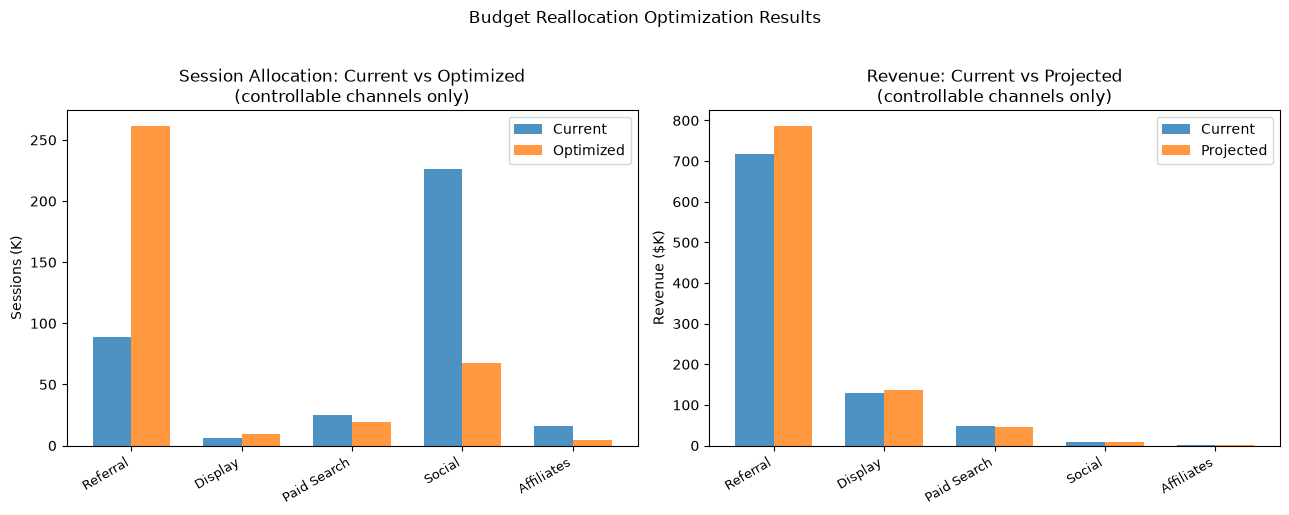

In [ ]:
# chart shows only controllable channels
df_plot_ctrl = df_ctrl_result.sort_values('session_change_pct', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x = np.arange(len(df_plot_ctrl))
width = 0.35

ax = axes[0]
ax.bar(x - width/2, df_plot_ctrl['sessions'] / 1000, width, label='Current', color='tab:blue', alpha=0.8)
ax.bar(x + width/2, df_plot_ctrl['opt_sessions'] / 1000, width, label='Optimized', color='tab:orange', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(df_plot_ctrl['channelGrouping'], rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Sessions (K)')
ax.set_title('Session Allocation: Current vs Optimized\n(controllable channels only)')
ax.legend()

ax = axes[1]
ax.bar(x - width/2, df_plot_ctrl['revenue'] / 1000, width, label='Current', color='tab:blue', alpha=0.8)
ax.bar(x + width/2, df_plot_ctrl['proj_revenue'] / 1000, width, label='Projected', color='tab:orange', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(df_plot_ctrl['channelGrouping'], rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Revenue ($K)')
ax.set_title('Revenue: Current vs Projected\n(controllable channels only)')
ax.legend()

plt.suptitle('Budget Reallocation Optimization Results', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../images/budget_reallocation.png', dpi=150, bbox_inches='tight')
plt.show()

**Insights:**

- **Referral absorbs nearly all reallocated sessions** - pushed close to its 3x ceiling, drawing sessions away from Social and Affiliates. Its log_coef is ~13x higher than Paid Search's and ~92x higher than Social's, so the optimizer strongly favors it until marginal yields equalize.
- **Display hits its 1.5x cap (+50%)** - second most efficient channel per session but constrained to prevent the attribution-inflated AOV from distorting the allocation further.
- **Social and Affiliates drop to the 30% floor (-70%)** - marginal yield near zero; the optimizer treats these as the primary source of sessions to reallocate.
- **Paid Search decreases despite being a controllable paid channel** - because Referral's marginal yield is so much higher, the optimizer takes sessions from Paid Search and gives them to Referral until their marginal yields equalize.
- **Fixed channels (Organic Search, Direct) are unchanged** - their revenue contribution is held constant; all gains come from reallocation within the five controllable channels.

## 7. Sensitivity Analysis
*How robust is the optimization recommendation?*

In [ ]:
def run_optimizer(a_test):
    """Re-run optimizer with a given log_coef array, return optimal sessions and revenue."""
    def _neg_rev(s):
        return -np.sum(a_test * np.log(s + 1))
    def _neg_rev_grad(s):
        return -a_test / (s + 1)
    res = optimize.minimize(
        _neg_rev, s0_ctrl, jac=_neg_rev_grad,
        method='SLSQP', bounds=bounds, constraints=constraints,
        options={'ftol': 1e-10, 'maxiter': 2000}
    )
    return res.x, -res.fun

referral_idx = channels_ctrl.index('Referral')

scenarios = {
    'Pessimistic (all ×0.8)': a_ctrl * 0.8,
    'Base':                   a_ctrl.copy(),
    'Optimistic (all ×1.2)':  a_ctrl * 1.2,
    'Referral ×0.8':          np.where(np.arange(len(a_ctrl)) == referral_idx, a_ctrl * 0.8, a_ctrl),
    'Referral ×0.5':          np.where(np.arange(len(a_ctrl)) == referral_idx, a_ctrl * 0.5, a_ctrl),
}

alloc_results = {}
rev_results   = {}

for label, a_test in scenarios.items():
    s_opt_test, rev_opt_test = run_optimizer(a_test)
    alloc_results[label] = s_opt_test.round(0).astype(int)
    # revenue is always evaluated on BASE log_coefs — comparing allocation quality on same footing
    rev_results[label] = np.sum(a_ctrl * np.log(s_opt_test + 1))

df_sens_alloc = pd.DataFrame(alloc_results, index=channels_ctrl)
df_sens_alloc.insert(0, 'Current', s0_ctrl.astype(int))

df_sens_rev = pd.DataFrame({
    'scenario': list(rev_results.keys()),
    'proj_revenue_at_base_coef': [round(v, 0) for v in rev_results.values()]
})

display(df_sens_alloc)
print()
display(df_sens_rev)

,Current,Pessimistic (all ×0.8),Base,Optimistic (all ×1.2),Referral ×0.8,Referral ×0.5
Social,226117,67835,67835,67835,67835,67835
Referral,88666,261183,261183,261183,256736,244260
Paid Search,25326,19442,19442,19442,23889,36365
Affiliates,16403,4921,4921,4921,4921,4921
Display,6262,9393,9393,9393,9393,9393


,scenario,proj_revenue_at_base_coef
0,Pessimistic (all ×0.8),976483.0
1,Base,976483.0
2,Optimistic (all ×1.2),976483.0
3,Referral ×0.8,976367.0
4,Referral ×0.5,975200.0


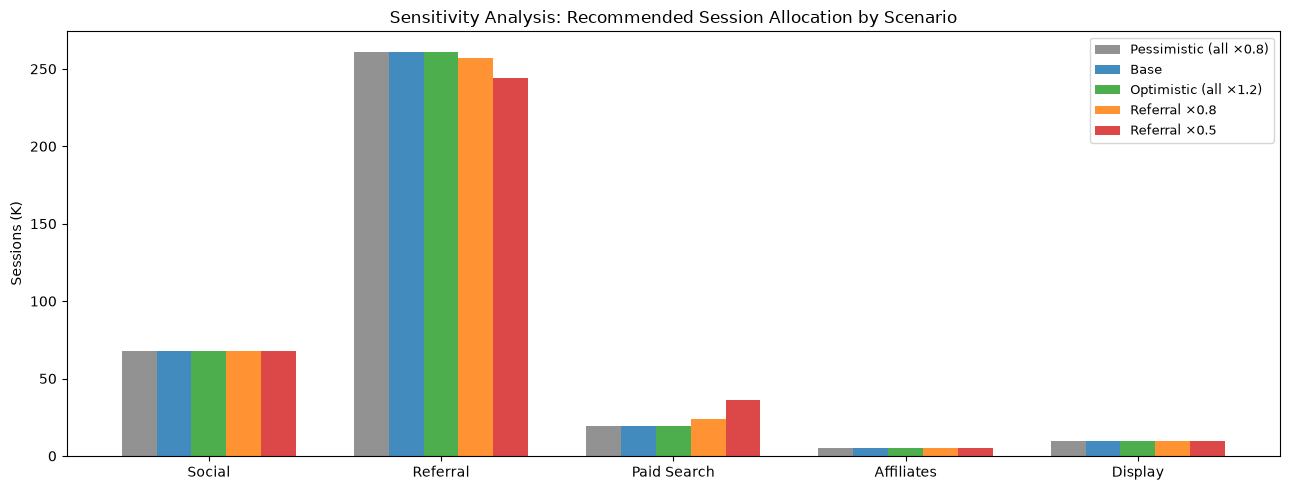

In [18]:
fig, ax = plt.subplots(figsize=(13, 5))

scenario_labels = list(alloc_results.keys())
x = np.arange(len(channels_ctrl))
n = len(scenario_labels)
width = 0.15
colors = ['tab:gray', 'tab:blue', 'tab:green', 'tab:orange', 'tab:red']

for i, (label, color) in enumerate(zip(scenario_labels, colors)):
    offset = (i - n / 2 + 0.5) * width
    ax.bar(x + offset, alloc_results[label] / 1000, width, label=label, color=color, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(channels_ctrl, fontsize=10)
ax.set_ylabel('Sessions (K)')
ax.set_title('Sensitivity Analysis: Recommended Session Allocation by Scenario')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../images/sensitivity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

**Observations:**

- **Uniform ±20% scaling leaves the allocation completely unchanged** - Pessimistic, Base, and Optimistic columns are identical. The optimizer responds to marginal yield *ratios* between channels; scaling all coefficients by the same factor does not change those ratios, so the optimal split is unaffected.
- **Discounting Referral gradually shifts sessions to Paid Search** - at ×0.8 the change is minor; at ×0.5 Paid Search recovers substantially. In both cases projected revenue at base coefficients barely changes, meaning the allocation remains near-optimal even under conservative Referral assumptions.
- **Social and Affiliates hit the 30% floor in every scenario** - no efficiency adjustment changes this. Their marginal yields are so far below every other channel that reallocation away from them is the most robust finding in the model.

## 8. Scenario Analysis
*3 interpretable reallocation scenarios without the optimizer - useful for stakeholder communication where a concrete story is needed.*

In [19]:
# helper: build a session array by applying multipliers to current values
# channels not listed keep their current sessions unchanged
idx = {ch: i for i, ch in enumerate(channels_ctrl)}

def make_scenario(multipliers):
    s = s0_ctrl.copy()
    for ch, mult in multipliers.items():
        s[idx[ch]] *= mult
    return s

# scenario definitions — grounded in sensitivity analysis findings:
# - Social and Affiliates should always be reduced (robust finding)
# - key uncertainty is whether to favour Referral or Paid Search with freed sessions
# - Display is efficient and capped, always boosted
scenarios_def = {
    'Baseline':                 make_scenario({}),
    'S1: Referral priority':    make_scenario({'Referral': 3.0, 'Display': 1.5, 'Social': 0.3, 'Affiliates': 0.3}),
    'S2: Paid Search priority': make_scenario({'Paid Search': 3.0, 'Display': 1.5, 'Social': 0.3, 'Affiliates': 0.3}),
    'S3: Moderate rebalance':   make_scenario({'Referral': 2.0, 'Paid Search': 1.5, 'Display': 1.5, 'Social': 0.5, 'Affiliates': 0.5}),
}

# compute projected revenue for each scenario using the log model
scenario_rev = {
    label: np.sum(a_ctrl * np.log(s_vec + 1))
    for label, s_vec in scenarios_def.items()
}

# session allocation per channel per scenario
print("=== Session Allocation ===")
df_scen_alloc = pd.DataFrame(
    {label: s_vec.round(0).astype(int) for label, s_vec in scenarios_def.items()},
    index=channels_ctrl
)
display(df_scen_alloc)

# revenue summary — include total sessions and revenue per session for fair cross-scenario comparison
baseline_rev = scenario_rev['Baseline']
print("\n=== Revenue Summary ===")
df_scen_rev = pd.DataFrame({
    'scenario':             list(scenario_rev.keys()),
    'total_sessions':       [int(s_vec.sum()) for s_vec in scenarios_def.values()],
    'proj_revenue':         [round(v, 0) for v in scenario_rev.values()],
    'vs_baseline':          [round(v - baseline_rev, 0) for v in scenario_rev.values()],
    'revenue_per_session':  [round(v / s_vec.sum(), 4)
                             for v, s_vec in zip(scenario_rev.values(), scenarios_def.values())],
})
display(df_scen_rev)

=== Session Allocation ===


,Baseline,S1: Referral priority,S2: Paid Search priority,S3: Moderate rebalance
Social,226117,67835,67835,113058
Referral,88666,265998,88666,177332
Paid Search,25326,25326,75978,37989
Affiliates,16403,4921,4921,8202
Display,6262,9393,9393,9393



=== Revenue Summary ===


,scenario,total_sessions,proj_revenue,vs_baseline,revenue_per_session
0,Baseline,362774,904531.0,0.0,2.4934
1,S1: Referral priority,373473,978873.0,74342.0,2.6210
2,S2: Paid Search priority,246792,914825.0,10294.0,3.7069
3,S3: Moderate rebalance,345974,955617.0,51086.0,2.7621


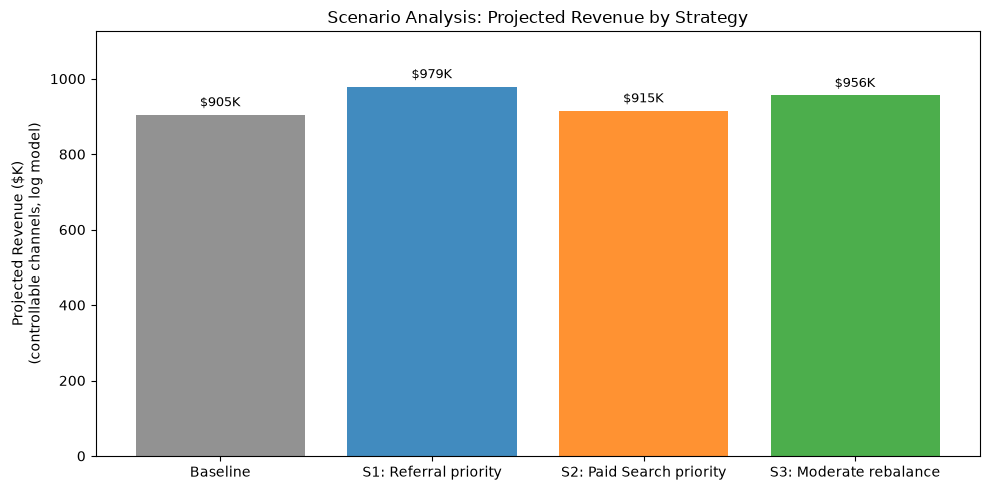

In [20]:
scenario_labels = list(scenarios_def.keys())
x = np.arange(len(scenario_labels))
colors = ['tab:gray', 'tab:blue', 'tab:orange', 'tab:green']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(x, [scenario_rev[l] / 1000 for l in scenario_labels], color=colors, alpha=0.85)
ax.bar_label(bars, fmt='$%.0fK', padding=4, fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(scenario_labels, fontsize=10)
ax.set_ylabel('Projected Revenue ($K)\n(controllable channels, log model)')
ax.set_title('Scenario Analysis: Projected Revenue by Strategy')
ax.margins(y=0.15)

plt.tight_layout()
plt.savefig('../images/scenario_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

**Insights:**

- **S1 projects the highest total revenue (+`$74K` vs baseline)** but uses more total sessions (373K vs 363K baseline) - the gain is partly from more total acquisition effort, not pure reallocation.
- **S2 has the highest revenue per session (`$3.71` vs `$2.49` baseline)** by replacing high-volume low-converting Social traffic with high-converting Paid Search. This is not a cost-efficiency measure: Social sessions are organic (near-zero cost), while every Paid Search session carries a CPC. S2 only makes sense if CPC per Paid Search session is less than the revenue that session generates. Without spend data this cannot be verified from this dataset.
- **S3 is the middle ground** - modest cuts to Social and Affiliates, doubling Referral and growing Paid Search by 50%. It produces `$51K` uplift with improved revenue per session and a less aggressive shift between channels.
- **All 3 scenarios beat baseline on projected revenue** - but session counts across channels do not represent equal investment. S2 in particular swaps free sessions for paid ones, so the true net gain depends entirely on actual CPC.

## 9. Summary

**Methodology note:** Session count is used as a budget proxy. The log saturation model is fitted from a single observation per channel, so curve shapes are assumed, not learned from data. All results are directional.

**Key findings:**

- **Cut Social and Affiliates** - the most robust finding across all sections. Near-zero marginal revenue yield in the log model, confirmed by sensitivity analysis: both channels hit the 30% floor in every scenario tested.
- **Referral is the highest-efficiency controllable channel** - log_coef ~13x Paid Search; optimizer assigns it nearly all freed sessions. Most of Referral's `$718K` revenue is last-non-direct-click attributed (users acquired via referral touchpoints who returned and purchased later), so growing this channel means more acquisition touchpoints, not necessarily more same-session revenue.
- **Display is capped, not trusted** - artificially limited to 1.5x because its high log_coef is an AOV attribution artifact, not genuine ad performance at scale.
- **Paid Search direction is uncertain** - the optimizer reduces it 23% because Referral's marginal yield dominates. Paid Search may be worth scaling if CPC is below revenue per session; this cannot be determined without spend data.

**Recommended scenario:** S3 (Moderate rebalance) - halve Social and Affiliates, double Referral, grow Paid Search and Display 50%. Projects +`$51K` vs baseline with the least aggressive channel shift, making it the most defensible recommendation given the data limitations.

**Critical data gap:** No ad spend data means the model optimizes sessions, not dollars. Before acting, obtain cost-per-session by channel. Once available, the optimizer can be reframed in dollars (maximize revenue minus cost, not just revenue) and the uncertainty between S2 and S3 becomes answerable with real numbers.